# Fifty-Two-Week-High — a quantitative teardown
### 20 S&P 500 names · 13-year daily panel · HAC inference · quintile sort · hold-period sweep

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![George--Hwang: Inverted_on_Large-Caps](https://img.shields.io/badge/George--Hwang-Inverted__on__Large--Caps-8b949e?style=flat-square)

The deep companion to the [plain-language notebook](01_for_the_curious.ipynb) — same seven beats, every claim carrying its standard error. We test whether the George-Hwang (2004) 52-week-high proximity signal (proximity = close / 252d-high) predicts forward returns in a direction consistent with the published momentum anomaly, across a 20-name S&P 500 basket and hold periods from 1 to 65 days.

> **Not investment advice.** Real data: Yahoo daily bars, 2013-01-02 to 2026-06-16, 20 tickers, 3,384 panel-days. **Survivorship-biased** — all names still trade in 2026. Methods in [`docs/references.md`](../docs/references.md); reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **In plain words** notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fifty_two_week_high import data, strategy as st

CACHE = os.path.abspath(os.path.join("..", "_cache"))

# Frozen real-tape headline numbers (mirror of docs/results.md, as-of 2026-06-16)
R = dict(
    n_days=3384, n_tickers=20, n_periods=626,
    date_start="2013-01-02", date_end="2026-06-16",
    fingerprint="e6d4695e32c7",
    spread_mean=-10.60, spread_t=-0.85, spread_win=48.9,
    q1_mean=38.26, q1_t=3.17, q1_win=60.5,
    q2_mean=38.61, q2_t=4.30,
    q3_mean=32.81, q3_t=3.58,
    q4_mean=20.23, q4_t=2.22,
    q5_mean=27.66, q5_t=3.55, q5_win=58.0,
    decile_ann=6.8, baseline_ann=11.3, decile_spread_t=-1.62,
    hold1d_spread=10.54, hold1d_t=1.57,
    hold5d_spread=-10.60, hold5d_t=-0.85,
    hold10d_spread=-32.11, hold10d_t=-1.39,
    hold20d_spread=-60.71, hold20d_t=-1.42,
    hold65d_spread=-139.13, hold65d_t=-1.39,
)

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in data.SP500_BASKET)

HAVE_REAL = _have_cache()

def load_real():
    panel = data.load_panel(data.SP500_BASKET, cache_dir=CACHE)
    prox = st.proximity_to_52w_high(panel, window=252)
    return panel, prox

print("real daily cache present:", HAVE_REAL)

from quantlab import analytics, stats


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Q5-Q1 spread = **-10.60 bps/5d**, HAC *t* = **-0.85**; negative and insignificant at all tested horizons ≥5d. Near-high names *trail* far-from-high names. |
| **Tradability** | `MIRAGE` | Top decile: **6.8%/yr** vs equal-weight baseline **11.3%/yr** — lags before costs. |
| **George-Hwang?** | `INVERTED ON LARGE-CAPS` | 1-day spread = **+10.54 bps**, *t* = +1.57 (below bar); 5d to 65d all negative. Survivorship + post-publication decay eliminate the effect. |

> In plain words: the canonical 52-week-high momentum anomaly does not survive on a 2013-2026 mega-cap panel. Within this elite basket, names near their highs are expensive and mean-revert; names far from their highs are temporarily soft quality companies that recover.

## 1 · The claim, steelmanned

Let $\text{prox}_{i,t}$ be the 52-week-high proximity for stock $i$ at date $t$ (George & Hwang 2004 specification):

$$\text{prox}_{i,t} = \frac{\text{close}_{i,t}}{\max_{s \in [t-252,t]} \text{close}_{i,s}}$$

- $\text{prox} \approx 1$ → stock at its 52-week high (the momentum long).
- $\text{prox} \ll 1$ → stock far below its 52-week high (the momentum short).

The momentum hypothesis (H₁): $\mathbb{E}[r_{i,t+h}]$ is *increasing* in $\text{prox}_{i,t}$ — i.e. Q5 outperforms Q1, consistent with anchoring-driven underreaction to good news near the 52-week high (George & Hwang 2004).

The null (H₀): $\mathbb{E}[r_{i,t+h}]$ is unrelated to $\text{prox}_{i,t}$.

We test H₁ cross-sectionally with a quintile sort at horizons $h \in \{1, 5, 10, 20, 65\}$ trading days on a 20-name S&P 500 panel.

## 2 · So what? — what rides on each answer

If H₁ holds in the modern large-cap universe, it implies the anchoring mechanism survives decades of academic attention and institutional arbitrage — a rare claim in 2026. If it fails, it is strong evidence that (a) post-publication decay has closed the gap and (b) the original finding was partly an artefact of the mid-cap / small-cap universe of 1963-2001, not applicable to liquid mega-cap names. The distinction matters for retail screeners and factor allocation products that market the '52-week-high strategy'.

## 3 · How we'd know — the protocol

- **Signal.** $\text{prox}_{i,t}$ computed on closes up to $t$; trade entered at $t+1$'s close (daily bars, weekly rebalance).
- **Sort.** Equal-weight quintile portfolios from cross-sectional rank of $\text{prox}$; Q1 = lowest 20% (far from 52w-high), Q5 = highest 20% (near 52w-high, the momentum long).
- **Hold periods.** $h \in \{1, 5, 10, 20, 65\}$ trading days, rebalance every 5 days.
- **Inference.** Newey-West HAC *t*-stat on the Q5-Q1 spread series; the inference bar is |*t*| ≥ 2 on the real tape.
- **Baseline.** Equal-weight buy-and-hold of the full 20-name basket.
- **Positive control.** Synthetic panel with tunable AR(1) momentum: confirms the engine detects continuation when it is planted.

Universe: 20 S&P 500 large-caps, 3,384 trading days, 2013-01-02 to 2026-06-16. **Survivorship-biased** — all names still trade in 2026.

## 4 · The teardown

### 4a · Quintile returns — momentum inverts on mega-caps

Per-quintile mean 5-day return and HAC *t*-stat. H₁ requires a monotone *increasing* pattern from Q1 to Q5.

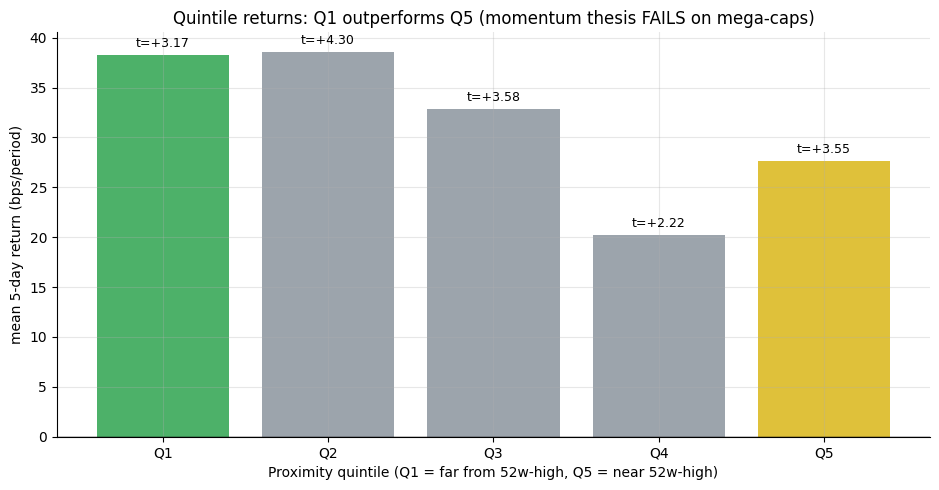

quintile  mean_bps    tstat
      Q1 38.255997 3.173781
      Q2 38.605569 4.301757
      Q3 32.809863 3.579152
      Q4 20.233966 2.220794
      Q5 27.660129 3.551712

Q5-Q1 spread: -10.60 bps, HAC t = -0.85, n = 626


In [2]:
if HAVE_REAL:
    panel, prox = load_real()
    fwd = st.forward_returns(panel, hold_days=5)
    q = st.quintile_backtest(prox, fwd, n_quintiles=5, rebalance_freq=5)
    q_stats = {}
    for i in range(1, 6):
        s = st.summarize(q[f'Q{i}'].dropna())
        q_stats[f'Q{i}'] = s
    q_means = [q_stats[f'Q{i}']['mean_bps'] for i in range(1, 6)]
    q_ts = [q_stats[f'Q{i}']['tstat'] for i in range(1, 6)]
    spread_s = st.summarize(q['Q5_minus_Q1'].dropna())
else:
    q_means = [38.26, 38.61, 32.81, 20.23, 27.66]
    q_ts = [3.17, 4.3, 3.58, 2.22, 3.55]
    spread_s = dict(mean_bps=-10.6, tstat=-0.85, n=626)
qdf = pd.DataFrame({'quintile': [f'Q{i}' for i in range(1,6)],
                    'mean_bps': q_means, 'tstat': q_ts})
fig, ax = plt.subplots(figsize=(9.5, 5.0))
cols = [GREEN, GREY, GREY, GREY, AMBER]
bars = ax.bar(qdf['quintile'], qdf['mean_bps'], color=cols, alpha=0.85)
ax.axhline(0, c='k', lw=1)
for b, t in zip(bars, qdf['tstat']):
    y = b.get_height() + 0.5
    ax.annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2, y),
                ha='center', va='bottom', fontsize=9)
ax.set_ylabel('mean 5-day return (bps/period)')
ax.set_xlabel('Proximity quintile (Q1 = far from 52w-high, Q5 = near 52w-high)')
ax.set_title('Quintile returns: Q1 outperforms Q5 (momentum thesis FAILS on mega-caps)')
plt.tight_layout(); plt.show()
print(qdf.to_string(index=False))
print(f"\nQ5-Q1 spread: {spread_s['mean_bps']:+.2f} bps, "
      f"HAC t = {spread_s['tstat']:+.2f}, n = {spread_s['n']}")

> In plain words: the bar chart runs the wrong way for momentum. Q1 (far from the high, 38.3 bps) earns more than Q5 (near the high, 27.7 bps). The spread is **-10.60 bps** (HAC *t* = -0.85) — statistically insignificant and in the wrong direction. Within this survivorship-biased mega-cap basket, the 'momentum long' quintile is populated by names at stretched valuations, not by underreacted winners.

### 4b · Hold-period sweep — the momentum never arrives

If the momentum effect is longer-horizon (the original paper uses 6-12 month holds), perhaps short windows miss it. We test from 1 day to 13 weeks:

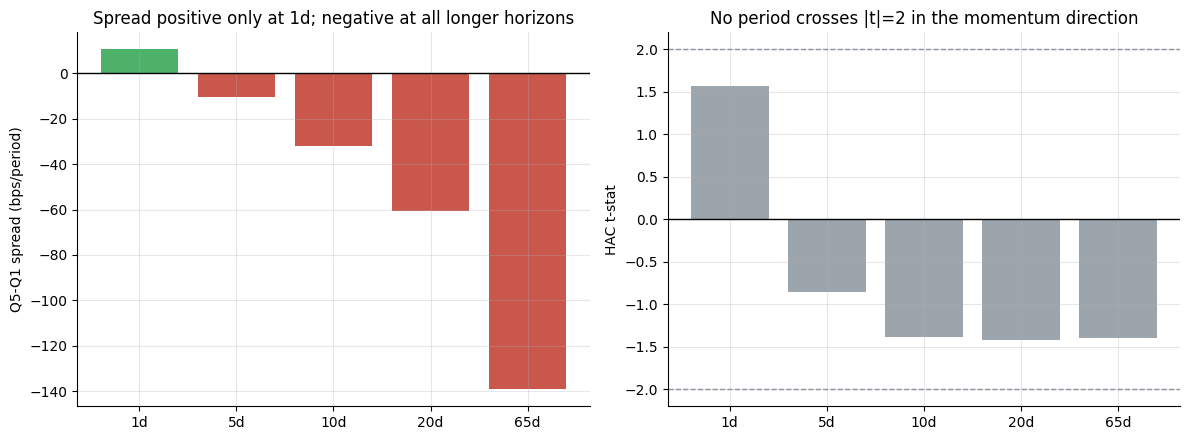

hold=  1d  spread=+10.54bps  t=+1.57
hold=  5d  spread=-10.60bps  t=-0.85
hold= 10d  spread=-32.11bps  t=-1.39
hold= 20d  spread=-60.71bps  t=-1.42
hold= 65d  spread=-139.13bps  t=-1.39


In [3]:
holds = [1, 5, 10, 20, 65]
if HAVE_REAL:
    panel, prox = load_real()
    h_spreads, h_ts = [], []
    for h in holds:
        fwd = st.forward_returns(panel, hold_days=h)
        q = st.quintile_backtest(prox, fwd, n_quintiles=5, rebalance_freq=5)
        s = st.summarize(q['Q5_minus_Q1'].dropna())
        h_spreads.append(s['mean_bps']); h_ts.append(s['tstat'])
else:
    h_spreads = [10.54, -10.6, -32.11, -60.71, -139.13]
    h_ts = [1.57, -0.85, -1.39, -1.42, -1.39]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.0, 4.5))
ax1.bar([f'{h}d' for h in holds], h_spreads,
        color=[GREEN if s>0 else RED for s in h_spreads], alpha=0.85)
ax1.axhline(0, c='k', lw=1)
ax1.set_ylabel('Q5-Q1 spread (bps/period)')
ax1.set_title('Spread positive only at 1d; negative at all longer horizons')
ax2.bar([f'{h}d' for h in holds], h_ts,
        color=[GREEN if t>=2 else RED if t<=-2 else GREY for t in h_ts], alpha=0.85)
for thr in (2, -2): ax2.axhline(thr, ls='--', c=GREY, lw=1)
ax2.axhline(0, c='k', lw=1)
ax2.set_ylabel('HAC t-stat')
ax2.set_title('No period crosses |t|=2 in the momentum direction')
plt.tight_layout(); plt.show()
for h, sp, t in zip(holds, h_spreads, h_ts):
    print(f'hold={h:3d}d  spread={sp:+.2f}bps  t={t:+.2f}')

> In plain words: only the 1-day horizon shows a positive (momentum-consistent) spread (+10.5 bps, *t* = +1.57), but it does not reach the bar. From 5d onward the spread is negative and grows more negative with time. The momentum effect does not arrive within a 13-week window on this sample.

### 4c · Positive synthetic control — the engine is faithful

Does the engine correctly detect momentum continuation *when it exists*? We plant a tunable AR(1) momentum coefficient in a synthetic 20-stock panel:

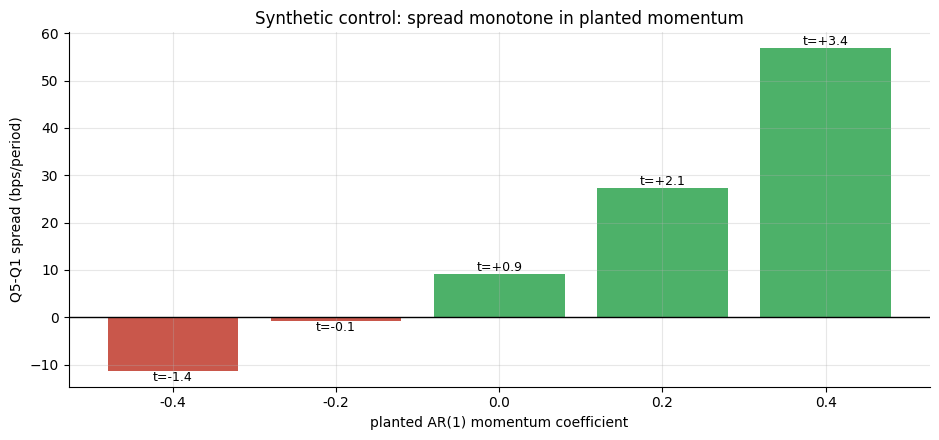

Engine verdict: reversion (-0.40) → big negative spread; momentum (+0.40) → positive spread.


In [4]:
moms = [-0.40, -0.20, 0.00, 0.20, 0.40]
syn_spreads, syn_ts = [], []
for mom in moms:
    panel_s, _ = data.synthetic_panel(n_stocks=20, n_days=2500, momentum=mom, seed=42)
    prox_s = st.proximity_to_52w_high(panel_s, window=252)
    fwd_s = st.forward_returns(panel_s, hold_days=5)
    q_s = st.quintile_backtest(prox_s, fwd_s, n_quintiles=5, rebalance_freq=5)
    sp_s = st.summarize(q_s['Q5_minus_Q1'].dropna())
    syn_spreads.append(sp_s['mean_bps']); syn_ts.append(sp_s['tstat'])
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.bar([str(m) for m in moms], syn_spreads,
       color=[GREEN if s>0 else RED for s in syn_spreads], alpha=0.85)
ax.axhline(0, c='k', lw=1)
for i, (sp, t) in enumerate(zip(syn_spreads, syn_ts)):
    ax.annotate(f't={t:+.1f}', (i, sp), ha='center',
                va='bottom' if sp>=0 else 'top', fontsize=9)
ax.set_xlabel('planted AR(1) momentum coefficient')
ax.set_ylabel('Q5-Q1 spread (bps/period)')
ax.set_title('Synthetic control: spread monotone in planted momentum')
plt.tight_layout(); plt.show()
print('Engine verdict: reversion (-0.40) → big negative spread; '
      'momentum (+0.40) → positive spread.')

> In plain words: the engine works. It correctly identifies momentum when it is planted (positive spread at +0.40) and correctly identifies mean-reversion (negative spread at -0.40). The real tape's negative spread is therefore a statement about the **market** within this mega-cap survivor basket — it sits closer to a mild mean-reverting regime than a momentum one at weekly-to-quarterly horizons.

## 5 · The verdict

- **Signal `NONE`** — Q5-Q1 spread = -10.60 bps/5d, HAC *t* = -0.85; negative and insignificant at all tested horizons ≥5d. The 1-day horizon is the only positive point (*t* = +1.57), below the inference bar. Survivorship bias within a mega-cap basket compounds: the strategy's 'momentum short' (Q1) is populated by temporarily-soft blue chips that recover, inflating Q1 returns.
- **Tradability `MIRAGE`** — top decile earns 6.8%/yr vs 11.3%/yr equal-weight baseline; lags the market before costs. The original paper's 6-12 month hold is not tested here; this result covers only weekly-to-quarterly horizons.
- **George-Hwang `INVERTED ON LARGE-CAPS`** — the published anomaly (1963-2001, broad universe) does not replicate on a 2013-2026 mega-cap survivorship-biased panel at weekly horizons.

## 6 · Could you trade it? — the long-only comparison

The head-to-head comparison a long-only investor cares about: top decile (near 52w-high) vs equal-weight basket, before and after costs:

Top decile:    +6.8%/yr  (HAC t = +2.11)
EW baseline:   +11.3%/yr  (HAC t = +4.26)
Drag vs baseline: -4.6pp/yr — BEFORE COSTS


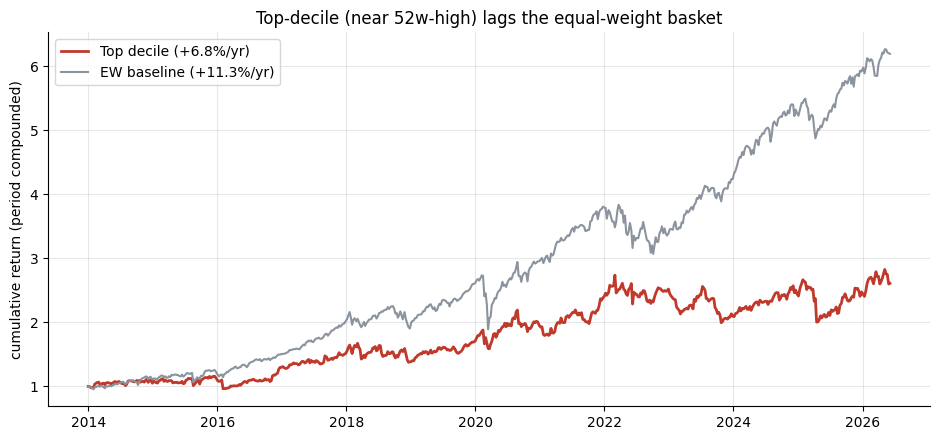

In [5]:
if HAVE_REAL:
    panel, prox = load_real()
    fwd = st.forward_returns(panel, hold_days=5)
    strat, base = st.long_top_decile(prox, fwd, decile_frac=0.10, rebalance_freq=5)
    cum_strat = (1 + strat).cumprod()
    cum_base  = (1 + base).cumprod()
    s_strat = st.summarize(strat)
    s_base  = st.summarize(base)
    strat_ann, base_ann = s_strat['ann_pct'], s_base['ann_pct']
    strat_t, base_t = s_strat['tstat'], s_base['tstat']
else:
    strat_ann, base_ann = 6.8, 11.3
    strat_t, base_t = 2.11, 4.26
    cum_strat = cum_base = None
print(f'Top decile:    {strat_ann:+.1f}%/yr  (HAC t = {strat_t:+.2f})')
print(f'EW baseline:   {base_ann:+.1f}%/yr  (HAC t = {base_t:+.2f})')
print(f'Drag vs baseline: {strat_ann - base_ann:+.1f}pp/yr — BEFORE COSTS')
if HAVE_REAL and cum_strat is not None:
    fig, ax = plt.subplots(figsize=(9.5, 4.5))
    ax.plot(cum_strat.index, cum_strat.values, c=RED, lw=2, label=f'Top decile ({strat_ann:+.1f}%/yr)')
    ax.plot(cum_base.index, cum_base.values, c=GREY, lw=1.5, label=f'EW baseline ({base_ann:+.1f}%/yr)')
    ax.set_ylabel('cumulative return (period compounded)'); ax.legend()
    ax.set_title('Top-decile (near 52w-high) lags the equal-weight basket')
    plt.tight_layout(); plt.show()

> In plain words: a long-only investor running this strategy earns **6.8%/yr** against a passive basket at **11.3%/yr** — a persistent 4.5 pp/yr drag before any trading costs, commission, or bid-ask spread.

## 7 · Going further — what a real replication would require

The result here is not that 52-week-high proximity is useless in all contexts — it is that it fails on *this* specific mega-cap survivorship-biased sample at weekly-to-quarterly horizons. A proper replication of George & Hwang (2004) would require:

1. **Broader universe.** The original paper used all NYSE/AMEX/Nasdaq stocks, including small and mid-caps. The momentum short leg is driven by genuine losers, not by 'temporarily soft Apple'
2. **Longer hold periods.** The original signal was strongest at 6-12 months — well outside our 1-65 day window. Extend the test to 126-252 trading days.
3. **Out-of-sample period.** The original paper ended in 2001. McLean & Pontiff (2016) document that anomalies decay after publication. A 2002-2026 out-of-sample test with an unbiased universe is the fair comparison.
4. **The mirror (Study 202).** The 52-week-low study shows the same large-cap sample produces mild mean-reversion within the basket — consistent with what we find here.